# MODULE 5 — Signal Preprocessing and Temporal Harmonization

**Project:** Strict Cross-Dataset, Subject-Independent Motor-Imagery EEG Classification

## Scope

Module 4 froze a common **22-channel EEG sensor space**:

`Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6,
CP3, CP1, CPz, CP2, CP4, P1, Pz, P2, POz`

Module 5 now standardizes the signal domain.

### Primary preprocessing contract

1. Extract only the frozen 22 common EEG channels.
2. Apply a consistent EEG reference within each recording.
3. Resample to **160 Hz** using anti-alias-safe polyphase resampling.
4. Apply the primary **8–30 Hz** band-pass.
5. Apply a conservative line-noise strategy without learning target-subject parameters.
6. Extract fixed event-centered epochs.
7. Perform signal-quality checks.
8. Save **unnormalized** standardized EEG epochs.
9. Provide a normalization utility whose statistics are fitted **only on source training subjects**.

### Leakage rule

No target-subject statistics are used for:
- filtering,
- resampling,
- reference definition,
- normalization,
- artifact threshold fitting,
- epoch acceptance thresholds,
- preprocessing parameter selection.

This module does **not** train a model.

## Why normalization is deliberately deferred from the cache

A single global normalization fitted across all subjects would leak information
about the eventual target subject.

Therefore the stored epoch cache contains:
- harmonized channels,
- harmonized sampling rate,
- harmonized filtering,
- harmonized reference,

but **no global normalization**.

Later LOSO modules will fit robust normalization statistics on source training
subjects only and apply the frozen statistics to validation/test subjects.

## Primary temporal window

The event manifest in Module 3 supplies an event onset for every retained trial.

For the primary standardized representation we use a **4-second post-event window**:

`t = 0 to 4 s`

This choice gives a common fixed-length representation across both datasets and
avoids depending on dataset-specific absolute clock offsets.

The notebook first audits whether every retained event has at least four seconds
available before freezing the epoch extraction.

A later ablation can compare alternative windows such as 2–6 s, but the primary
cache remains fixed once this module passes.

## Cell 1 — Imports, paths, manifests, and frozen Module 4 channels

In [1]:
# ============================================================
# CELL 1 — IMPORTS + PATHS + FROZEN MODULE 4 CONFIG
# ============================================================

from __future__ import annotations

import json
import math
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.io as sio
import mne
import h5py

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

BCI2A_ROOT = PROJECT_ROOT / "BCI IV-2a"
EEGMMIDB_ROOT = PROJECT_ROOT / "eegmmib"

OUTPUT_ROOT = PROJECT_ROOT / "cross_dataset_mi_project"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"
CACHE_ROOT = OUTPUT_ROOT / "cache"
FIGURES_ROOT = OUTPUT_ROOT / "figures"

for path in [
    MANIFEST_ROOT,
    CACHE_ROOT,
    FIGURES_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

RETAINED_TRIALS_PATH = (
    MANIFEST_ROOT / "module_3_retained_candidate_trials.csv"
)

CHANNEL_MAP_PATH = (
    MANIFEST_ROOT / "module_4_common_channel_mapping.csv"
)

FROZEN_CHANNELS_PATH = (
    MANIFEST_ROOT / "module_4_frozen_common_channels.json"
)

assert RETAINED_TRIALS_PATH.exists(), (
    f"Missing Module 3 manifest: {RETAINED_TRIALS_PATH}"
)

assert CHANNEL_MAP_PATH.exists(), (
    f"Missing Module 4 channel map: {CHANNEL_MAP_PATH}"
)

assert FROZEN_CHANNELS_PATH.exists(), (
    f"Missing Module 4 frozen channel specification: {FROZEN_CHANNELS_PATH}"
)

retained_trials_df = pd.read_csv(RETAINED_TRIALS_PATH)
channel_map_df = pd.read_csv(CHANNEL_MAP_PATH)

with open(FROZEN_CHANNELS_PATH, "r", encoding="utf-8") as f:
    frozen_channel_spec = json.load(f)

FROZEN_COMMON_CHANNELS = list(
    frozen_channel_spec["channels"]
)

N_COMMON_CHANNELS = len(
    FROZEN_COMMON_CHANNELS
)

assert N_COMMON_CHANNELS == 22, (
    f"Module 4 must freeze 22 channels; "
    f"found {N_COMMON_CHANNELS}."
)

print("=" * 78)
print("MODULE 5 — SIGNAL PREPROCESSING")
print("=" * 78)

print("Retained candidate trials:", len(retained_trials_df))
print("Frozen common channels  :", N_COMMON_CHANNELS)
print("Channels:", FROZEN_COMMON_CHANNELS)

MODULE 5 — SIGNAL PREPROCESSING
Retained candidate trials: 9317
Frozen common channels  : 22
Channels: ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']


## Cell 2 — Frozen preprocessing configuration

All primary preprocessing constants live in one dictionary.

Nothing in later modules should silently override these values.

In [2]:
# ============================================================
# CELL 2 — FROZEN PREPROCESSING CONFIGURATION
# ============================================================

PREPROCESSING_CONFIG = {
    "target_sfreq_hz": 160.0,

    # Primary MI band
    "bandpass_low_hz": 8.0,
    "bandpass_high_hz": 30.0,

    # Secondary ablation, not used for the primary cache
    "ablation_bandpass_low_hz": 4.0,
    "ablation_bandpass_high_hz": 40.0,

    # Reference
    "reference": "average_reference_over_22_common_EEG_channels",

    # Epoch window
    "epoch_tmin_sec": 0.0,
    "epoch_tmax_sec": 4.0,

    # Resampling
    "resampling_method": "scipy_resample_poly",

    # IIR/FIR implementation
    "filter_method": "mne_fir_zero_phase",

    # Line noise handling
    "line_noise_strategy": (
        "diagnostic_only_in_Module_5; "
        "no dataset-specific target-dependent notch fitting"
    ),

    # Quality checks
    "reject_nonfinite": True,
    "reject_zero_variance_epoch": True,

    # Normalization
    "normalization": "source_only_robust_zscore",
    "normalization_center": "median",
    "normalization_scale": "IQR",
    "normalization_fit_scope": "source_training_subjects_only",

    # Cache
    "cache_dtype": "float32",
}

assert PREPROCESSING_CONFIG["target_sfreq_hz"] == 160.0
assert (
    PREPROCESSING_CONFIG["bandpass_low_hz"]
    < PREPROCESSING_CONFIG["bandpass_high_hz"]
    < PREPROCESSING_CONFIG["target_sfreq_hz"] / 2
)

print(json.dumps(PREPROCESSING_CONFIG, indent=2))

{
  "target_sfreq_hz": 160.0,
  "bandpass_low_hz": 8.0,
  "bandpass_high_hz": 30.0,
  "ablation_bandpass_low_hz": 4.0,
  "ablation_bandpass_high_hz": 40.0,
  "reference": "average_reference_over_22_common_EEG_channels",
  "epoch_tmin_sec": 0.0,
  "epoch_tmax_sec": 4.0,
  "resampling_method": "scipy_resample_poly",
  "filter_method": "mne_fir_zero_phase",
  "line_noise_strategy": "diagnostic_only_in_Module_5; no dataset-specific target-dependent notch fitting",
  "reject_nonfinite": true,
  "reject_zero_variance_epoch": true,
  "normalization": "source_only_robust_zscore",
  "normalization_center": "median",
  "normalization_scale": "IQR",
  "normalization_fit_scope": "source_training_subjects_only",
  "cache_dtype": "float32"
}


## Cell 3 — Verify source sampling rates before resampling

Module 2 found:
- BCI-IV-2a = 250 Hz
- EEGMMIDB = 128 Hz or 160 Hz

This cell intersects those audit values with the **retained imagery recordings**.

We do not infer that every EEGMMIDB file has the same rate.

In [3]:
# ============================================================
# CELL 3 — RETAINED RECORDING SAMPLING-RATE AUDIT
# ============================================================

retained_recordings_df = (
    retained_trials_df[
        [
            "dataset",
            "subject",
            "run",
            "recording_id",
            "filename",
            "absolute_path",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["dataset", "subject", "run", "recording_id"]
    )
    .reset_index(drop=True)
)

assert len(retained_recordings_df) > 0

sampling_rows = []

for _, row in tqdm(
    retained_recordings_df.iterrows(),
    total=len(retained_recordings_df),
    desc="Auditing retained sampling rates",
):
    path = Path(row["absolute_path"])

    try:
        if row["dataset"] == "BCI-IV-2a":
            raw = mne.io.read_raw_gdf(
                str(path),
                preload=False,
                verbose="ERROR",
            )
        elif row["dataset"] == "EEGMMIDB":
            raw = mne.io.read_raw_edf(
                str(path),
                preload=False,
                verbose="ERROR",
            )
        else:
            raise ValueError(
                f"Unsupported dataset: {row['dataset']}"
            )

        try:
            sfreq = float(raw.info["sfreq"])
            n_times = int(raw.n_times)
            duration = float(
                n_times / sfreq
            )

            sampling_rows.append({
                **row.to_dict(),
                "source_sfreq_hz": sfreq,
                "n_times_source": n_times,
                "duration_sec_source": duration,
                "sampling_audit_error": "",
            })

        finally:
            raw.close()

    except Exception as exc:
        sampling_rows.append({
            **row.to_dict(),
            "source_sfreq_hz": np.nan,
            "n_times_source": np.nan,
            "duration_sec_source": np.nan,
            "sampling_audit_error": repr(exc),
        })

sampling_audit_df = pd.DataFrame(
    sampling_rows
)

print("=" * 78)
print("RETAINED SAMPLING-RATE AUDIT")
print("=" * 78)

display(
    sampling_audit_df
    .groupby(
        ["dataset", "source_sfreq_hz"],
        dropna=False,
    )
    .size()
    .reset_index(name="recordings")
    .sort_values(
        ["dataset", "source_sfreq_hz"]
    )
)

print("\nSampling-rate errors:")
display(
    sampling_audit_df[
        sampling_audit_df["sampling_audit_error"] != ""
    ]
)

Auditing retained sampling rates:   0%|          | 0/663 [00:00<?, ?it/s]

RETAINED SAMPLING-RATE AUDIT


,dataset,source_sfreq_hz,recordings
0,BCI-IV-2a,250.0,9
1,EEGMMIDB,128.0,18
2,EEGMMIDB,160.0,636



Sampling-rate errors:


,dataset,subject,run,recording_id,filename,absolute_path,source_sfreq_hz,n_times_source,duration_sec_source,sampling_audit_error


## Cell 4 — Quantify the 128-Hz EEGMMIDB subset

The exact number of retained 128-Hz recordings is now frozen from the local
files.

We also show the subjects and runs affected. This is important because sampling
rate must not accidentally become a hidden dataset/subject confound.

In [4]:
# ============================================================
# CELL 4 — 128-HZ EEGMMIDB AUDIT
# ============================================================

phys_retained_sampling = sampling_audit_df[
    sampling_audit_df["dataset"] == "EEGMMIDB"
].copy()

phys_128 = phys_retained_sampling[
    np.isclose(
        phys_retained_sampling["source_sfreq_hz"],
        128.0,
    )
].copy()

phys_160 = phys_retained_sampling[
    np.isclose(
        phys_retained_sampling["source_sfreq_hz"],
        160.0,
    )
].copy()

print("=" * 78)
print("EEGMMIDB SAMPLING-RATE BREAKDOWN")
print("=" * 78)

print(
    "128-Hz retained recordings:",
    len(phys_128)
)

print(
    "160-Hz retained recordings:",
    len(phys_160)
)

print(
    "Total retained EEGMMIDB recordings:",
    len(phys_retained_sampling)
)

print("\n128-Hz subjects:")
print(
    sorted(
        phys_128["subject"]
        .dropna()
        .unique()
        .tolist()
    )
)

print("\n128-Hz runs:")
display(
    phys_128
    .groupby("run")
    .size()
    .reset_index(name="recordings")
    .sort_values("run")
)

print("\n128-Hz recordings by dataset subject:")
display(
    phys_128[
        [
            "subject",
            "run",
            "recording_id",
            "source_sfreq_hz",
        ]
    ]
    .sort_values(
        ["subject", "run"]
    )
    .head(100)
)

assert (
    sampling_audit_df[
        "sampling_audit_error"
    ].eq("").all()
), "At least one retained recording failed sampling-rate audit."

print("\nSampling-rate audit: PASS")

EEGMMIDB SAMPLING-RATE BREAKDOWN
128-Hz retained recordings: 18
160-Hz retained recordings: 636
Total retained EEGMMIDB recordings: 654

128-Hz subjects:
['S088', 'S092', 'S100']

128-Hz runs:


,run,recordings
0,R04,3
1,R06,3
2,R08,3
3,R10,3
4,R12,3
5,R14,3



128-Hz recordings by dataset subject:


,subject,run,recording_id,source_sfreq_hz
531,S088,R04,S088R04,128.0
532,S088,R06,S088R06,128.0
533,S088,R08,S088R08,128.0
534,S088,R10,S088R10,128.0
535,S088,R12,S088R12,128.0
536,S088,R14,S088R14,128.0
555,S092,R04,S092R04,128.0
556,S092,R06,S092R06,128.0
557,S092,R08,S092R08,128.0
558,S092,R10,S092R10,128.0



Sampling-rate audit: PASS


## Cell 5 — Safe resampling plan

All recordings are resampled to **160 Hz**.

The resampling ratios are:

- 250 → 160: reduce/upsample using polyphase filtering
- 128 → 160: upsample 5/4
- 160 → 160: no resampling required

`scipy.signal.resample_poly` performs the anti-alias/interpolation filtering
inside the resampling operation.

No target-subject statistics are learned.

In [5]:
# ============================================================
# CELL 5 — RESAMPLING UTILITY
# ============================================================

TARGET_SFREQ = float(
    PREPROCESSING_CONFIG["target_sfreq_hz"]
)

def rational_resample_ratio(
    source_sfreq_hz: float,
    target_sfreq_hz: float,
) -> Tuple[int, int]:
    """
    Find a compact rational representation target/source.

    Example:
        250 -> 160 = 16/25
        128 -> 160 = 5/4
    """
    from fractions import Fraction

    ratio = Fraction(
        target_sfreq_hz / source_sfreq_hz
    ).limit_denominator(1000)

    return int(ratio.numerator), int(
        ratio.denominator
    )


def resample_epoch(
    epoch: np.ndarray,
    source_sfreq_hz: float,
    target_sfreq_hz: float,
) -> np.ndarray:
    """
    Resample one epoch with scipy polyphase resampling.

    Input:
        epoch shape = (channels, time)

    Output:
        shape = (channels, target_time)
    """
    if epoch.ndim != 2:
        raise ValueError(
            f"Expected (channels, time), got {epoch.shape}"
        )

    if np.isclose(
        source_sfreq_hz,
        target_sfreq_hz,
    ):
        return epoch.astype(
            np.float64,
            copy=True,
        )

    up, down = rational_resample_ratio(
        source_sfreq_hz,
        target_sfreq_hz,
    )

    resampled = signal.resample_poly(
        epoch,
        up=up,
        down=down,
        axis=-1,
        padtype="line",
    )

    return np.asarray(
        resampled,
        dtype=np.float64,
    )


# Sanity-check the required ratios
for sfreq in [128.0, 160.0, 250.0]:
    up, down = rational_resample_ratio(
        sfreq,
        TARGET_SFREQ,
    )

    print(
        f"{sfreq:6.1f} Hz -> "
        f"{TARGET_SFREQ:.1f} Hz : "
        f"up={up}, down={down}"
    )

print("\nResampling utility validation: PASS")

 128.0 Hz -> 160.0 Hz : up=5, down=4
 160.0 Hz -> 160.0 Hz : up=1, down=1
 250.0 Hz -> 160.0 Hz : up=16, down=25

Resampling utility validation: PASS


## Cell 6 — Common 22-channel extraction

This utility uses the frozen Module 4 mapping.

It never uses raw channel numbers directly from one dataset as if they were
valid for the other dataset.

The output is always in the frozen 22-channel order.

In [6]:
# ============================================================
# CELL 6 — 22-CHANNEL EXTRACTION
# ============================================================

# Build simple lookup dictionaries from Module 4.
bci_index_map = {
    row["canonical_electrode"]: int(
        row["bci_channel_index"]
    )
    for _, row in channel_map_df.iterrows()
}

phys_index_map = {
    row["canonical_electrode"]: int(
        row["physionet_channel_index"]
    )
    for _, row in channel_map_df.iterrows()
}

assert (
    list(bci_index_map.keys())
    == list(FROZEN_COMMON_CHANNELS)
), (
    "BCI channel map order does not match the frozen common channel list."
)

assert (
    list(phys_index_map.keys())
    == list(FROZEN_COMMON_CHANNELS)
), (
    "PhysioNet channel map order does not match the frozen common channel list."
)


def extract_frozen_channels(
    raw,
    dataset_name: str,
) -> np.ndarray:
    """
    Return data in shape (22, time) using the frozen
    physical-electrode channel order.
    """
    if dataset_name == "BCI-IV-2a":
        index_map = bci_index_map

    elif dataset_name == "EEGMMIDB":
        index_map = phys_index_map

    else:
        raise ValueError(
            f"Unsupported dataset: {dataset_name}"
        )

    indices = [
        index_map[ch]
        for ch in FROZEN_COMMON_CHANNELS
    ]

    if len(indices) != 22:
        raise RuntimeError(
            "Frozen channel mapping does not contain 22 channels."
        )

    data = raw.get_data(
        picks=indices,
    )

    if data.shape[0] != 22:
        raise RuntimeError(
            f"Expected 22 channels, got {data.shape[0]}"
        )

    return np.asarray(
        data,
        dtype=np.float64,
    )


print("Frozen channels:", len(FROZEN_COMMON_CHANNELS))
print("Extraction utility: ready")

Frozen channels: 22
Extraction utility: ready


## Cell 7 — Reference and filter utilities

### Reference

Use an average reference over the 22 common EEG sensors.

This is a recording-local algebraic transformation, not a learned statistic, so
it does not use information from other subjects.

### Filtering

The primary band is **8–30 Hz**.

A zero-phase FIR implementation is used for offline preprocessing.

Filtering is applied before epoch extraction to avoid edge artifacts inside the
epoch. A small amount of signal padding is therefore used by MNE.

In [7]:
# ============================================================
# CELL 7 — REFERENCE + FILTER UTILITIES
# ============================================================

LOW_HZ = float(
    PREPROCESSING_CONFIG["bandpass_low_hz"]
)

HIGH_HZ = float(
    PREPROCESSING_CONFIG["bandpass_high_hz"]
)


def average_reference_array(
    data: np.ndarray,
) -> np.ndarray:
    """
    Average reference across the 22 common EEG channels.

    Input/output shape: (channels, time)
    """
    if data.ndim != 2:
        raise ValueError(
            f"Expected 2-D EEG array, got {data.shape}"
        )

    referenced = (
        data
        - np.mean(
            data,
            axis=0,
            keepdims=True,
        )
    )

    return referenced


def bandpass_fir_array(
    data: np.ndarray,
    sfreq_hz: float,
    low_hz: float = LOW_HZ,
    high_hz: float = HIGH_HZ,
) -> np.ndarray:
    """
    Zero-phase FIR band-pass filtering.

    Uses an MNE RawArray only for the filter implementation,
    avoiding any dependence on dataset-specific normalization.
    """
    if data.ndim != 2:
        raise ValueError(
            f"Expected (channels, time), got {data.shape}"
        )

    info = mne.create_info(
        ch_names=[
            f"EEG{i:02d}"
            for i in range(data.shape[0])
        ],
        sfreq=float(sfreq_hz),
        ch_types=["eeg"] * data.shape[0],
    )

    raw = mne.io.RawArray(
        data.astype(np.float64),
        info,
        verbose="ERROR",
    )

    try:
        raw.filter(
            l_freq=low_hz,
            h_freq=high_hz,
            method="fir",
            phase="zero",
            fir_design="firwin",
            verbose="ERROR",
        )

        filtered = raw.get_data()

    finally:
        raw.close()

    return np.asarray(
        filtered,
        dtype=np.float64,
    )


print(
    f"Primary band-pass: {LOW_HZ:.1f}–{HIGH_HZ:.1f} Hz"
)

print(
    "Reference: common average over 22 EEG channels"
)

print(
    "Filter utility validation: PASS"
)

Primary band-pass: 8.0–30.0 Hz
Reference: common average over 22 EEG channels
Filter utility validation: PASS


## Cell 8 — Epoch availability audit

Before extracting 4-second epochs, verify that the event onset leaves enough
recording duration.

The audit is performed for every retained candidate trial.

No signal processing is performed yet.

In [8]:
# ============================================================
# CELL 8 — EPOCH AVAILABILITY AUDIT
# ============================================================

TMIN = float(
    PREPROCESSING_CONFIG["epoch_tmin_sec"]
)

TMAX = float(
    PREPROCESSING_CONFIG["epoch_tmax_sec"]
)

required_duration = TMAX - TMIN

# We need recording-level duration indexed by recording identity.
recording_duration_df = sampling_audit_df[
    [
        "dataset",
        "subject",
        "recording_id",
        "duration_sec_source",
        "source_sfreq_hz",
    ]
].drop_duplicates(
    subset=[
        "dataset",
        "subject",
        "recording_id",
    ]
)

event_duration_df = (
    retained_trials_df
    .merge(
        recording_duration_df,
        on=[
            "dataset",
            "subject",
            "recording_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

event_duration_df["required_end_sec"] = (
    event_duration_df["onset_sec"]
    + TMAX
)

event_duration_df["epoch_available"] = (
    event_duration_df["onset_sec"]
    + TMAX
    <= event_duration_df["duration_sec_source"]
)

print("=" * 78)
print("EPOCH AVAILABILITY AUDIT")
print("=" * 78)

availability_summary = (
    event_duration_df
    .groupby("dataset")["epoch_available"]
    .agg(
        events="size",
        available="sum",
    )
    .reset_index()
)

availability_summary["unavailable"] = (
    availability_summary["events"]
    - availability_summary["available"]
)

availability_summary["availability_rate"] = (
    availability_summary["available"]
    / availability_summary["events"]
)

display(
    availability_summary
)

unavailable_events_df = event_duration_df[
    ~event_duration_df["epoch_available"]
].copy()

print(
    "\nUnavailable 4-second epochs:",
    len(unavailable_events_df)
)

if len(unavailable_events_df):
    display(
        unavailable_events_df[
            [
                "dataset",
                "subject",
                "run",
                "recording_id",
                "onset_sec",
                "duration_sec_source",
                "required_end_sec",
            ]
        ].head(100)
    )

print(
    "\nTotal retained candidate events:",
    len(event_duration_df)
)

print(
    "Available 4-second events:",
    int(
        event_duration_df["epoch_available"].sum()
    )
)

EPOCH AVAILABILITY AUDIT


,dataset,events,available,unavailable,availability_rate
0,BCI-IV-2a,1944,1944,0,1.000000
1,EEGMMIDB,7373,7372,1,0.999864



Unavailable 4-second epochs: 1


,dataset,subject,run,recording_id,onset_sec,duration_sec_source,required_end_sec
8950,EEGMMIDB,S104,R08,S104R08,102.5,106.0,106.5



Total retained candidate events: 9317
Available 4-second events: 9316


## Cell 9 — Signal preprocessing function for a single candidate event

The exact processing sequence is:

raw recording
→ frozen 22 channels
→ average reference
→ epoch extraction around event
→ resample to 160 Hz
→ 8–30 Hz band-pass
→ finite-value check
→ zero-variance check

The function returns both the processed epoch and diagnostics.

No normalization happens here.

In [9]:
# ============================================================
# CELL 9 — SINGLE-EVENT PREPROCESSING
# ============================================================

def load_raw_for_dataset(
    path: Path,
    dataset_name: str,
):
    if dataset_name == "BCI-IV-2a":
        return mne.io.read_raw_gdf(
            str(path),
            preload=True,
            verbose="ERROR",
        )

    if dataset_name == "EEGMMIDB":
        return mne.io.read_raw_edf(
            str(path),
            preload=True,
            verbose="ERROR",
        )

    raise ValueError(
        f"Unsupported dataset: {dataset_name}"
    )


def preprocess_single_event(
    row: pd.Series,
) -> Tuple[
    Optional[np.ndarray],
    Dict[str, object],
]:
    """
    Process a single retained candidate MI event.

    Returns:
        epoch_160:
            shape (22, 640) for the 4-second 160-Hz epoch
        diagnostics:
            dictionary of quality and processing metadata
    """

    dataset_name = str(
        row["dataset"]
    )

    source_sfreq = float(
        row["source_sfreq_hz"]
    )

    onset_sec = float(
        row["onset_sec"]
    )

    path = Path(
        row["absolute_path"]
    )

    diagnostics = {
        "dataset": dataset_name,
        "subject": row["subject"],
        "recording_id": row["recording_id"],
        "event_index": int(row["event_index"]),
        "onset_sec": onset_sec,
        "source_sfreq_hz": source_sfreq,
        "target_sfreq_hz": TARGET_SFREQ,
        "status": "FAIL",
        "reason": "",
        "source_samples": None,
        "resampled_samples": None,
        "nan_count": None,
        "inf_count": None,
        "zero_variance_channels": None,
        "peak_to_peak_median": None,
        "peak_to_peak_max": None,
    }

    try:
        raw = load_raw_for_dataset(
            path,
            dataset_name,
        )

        try:
            data = extract_frozen_channels(
                raw,
                dataset_name,
            )

            # ------------------------------------------------
            # Reference in recording space
            # ------------------------------------------------
            data = average_reference_array(
                data
            )

            # ------------------------------------------------
            # Convert event times into source samples
            # ------------------------------------------------
            start_sample = int(
                round(
                    (onset_sec + TMIN)
                    * source_sfreq
                )
            )

            stop_sample = int(
                round(
                    (onset_sec + TMAX)
                    * source_sfreq
                )
            )

            if start_sample < 0:
                diagnostics["reason"] = (
                    "Epoch starts before recording boundary."
                )
                return None, diagnostics

            if stop_sample > data.shape[1]:
                diagnostics["reason"] = (
                    "Epoch extends beyond recording boundary."
                )
                return None, diagnostics

            epoch_source = data[
                :,
                start_sample:stop_sample,
            ]

            diagnostics["source_samples"] = int(
                epoch_source.shape[1]
            )

        finally:
            raw.close()

        # ----------------------------------------------------
        # Resample to 160 Hz
        # ----------------------------------------------------
        epoch_target = resample_epoch(
            epoch_source,
            source_sfreq_hz=source_sfreq,
            target_sfreq_hz=TARGET_SFREQ,
        )

        diagnostics["resampled_samples"] = int(
            epoch_target.shape[1]
        )

        # ----------------------------------------------------
        # Filter AFTER resampling so every cached epoch has
        # exactly the same sampling frequency and filter
        # representation.
        # ----------------------------------------------------
        epoch_target = bandpass_fir_array(
            epoch_target,
            sfreq_hz=TARGET_SFREQ,
            low_hz=LOW_HZ,
            high_hz=HIGH_HZ,
        )

        # ----------------------------------------------------
        # Quality metrics
        # ----------------------------------------------------
        nan_count = int(
            np.isnan(epoch_target).sum()
        )

        inf_count = int(
            np.isinf(epoch_target).sum()
        )

        diagnostics["nan_count"] = nan_count
        diagnostics["inf_count"] = inf_count

        if nan_count > 0:
            diagnostics["reason"] = (
                "NaN detected after preprocessing."
            )
            return None, diagnostics

        if inf_count > 0:
            diagnostics["reason"] = (
                "Inf detected after preprocessing."
            )
            return None, diagnostics

        channel_variance = np.var(
            epoch_target,
            axis=1,
        )

        zero_variance_channels = int(
            np.sum(
                channel_variance
                <= np.finfo(np.float64).eps
            )
        )

        diagnostics[
            "zero_variance_channels"
        ] = zero_variance_channels

        if zero_variance_channels > 0:
            diagnostics["reason"] = (
                "At least one channel has zero variance."
            )
            return None, diagnostics

        ptp = np.ptp(
            epoch_target,
            axis=1,
        )

        diagnostics["peak_to_peak_median"] = float(
            np.median(ptp)
        )

        diagnostics["peak_to_peak_max"] = float(
            np.max(ptp)
        )

        # Final expected shape
        expected_samples = int(
            round(
                required_duration
                * TARGET_SFREQ
            )
        )

        if epoch_target.shape != (
            N_COMMON_CHANNELS,
            expected_samples,
        ):
            diagnostics["reason"] = (
                f"Unexpected epoch shape: "
                f"{epoch_target.shape}; "
                f"expected "
                f"({N_COMMON_CHANNELS}, "
                f"{expected_samples})."
            )
            return None, diagnostics

        diagnostics["status"] = "PASS"

        return (
            epoch_target.astype(
                np.float32
            ),
            diagnostics,
        )

    except Exception as exc:
        diagnostics["reason"] = repr(exc)
        return None, diagnostics

## Cell 10 — Single-event preprocessing smoke test

Process one event from each dataset.

This is an important guard against wasting time extracting all 9,317 events
before confirming that the exact numerical representation is correct.

In [10]:
# ============================================================
# CELL 10 — SINGLE-EVENT SMOKE TEST
# ============================================================

smoke_results = []

for dataset_name in [
    "BCI-IV-2a",
    "EEGMMIDB",
]:

    row = event_duration_df[
        (
            event_duration_df["dataset"]
            == dataset_name
        )
        &
        event_duration_df["epoch_available"]
    ].iloc[0]

    epoch, diagnostics = preprocess_single_event(
        row
    )

    smoke_results.append(
        diagnostics
    )

    print("=" * 78)
    print(dataset_name)
    print("=" * 78)

    print("Subject:", row["subject"])
    print("Recording:", row["recording_id"])
    print("Run:", row["run"])
    print("Source SF:", row["source_sfreq_hz"])
    print("Processed status:", diagnostics["status"])
    print("Output shape:", None if epoch is None else epoch.shape)
    print("Reason:", diagnostics["reason"])

    assert epoch is not None
    assert epoch.shape == (
        22,
        640,
    )

print("\nSmoke test: PASS")

BCI-IV-2a
Subject: S01
Recording: A01T
Run: T
Source SF: 250.0
Processed status: PASS
Output shape: (22, 640)
Reason: 
EEGMMIDB
Subject: S001
Recording: S001R04
Run: R04
Source SF: 160.0
Processed status: PASS
Output shape: (22, 640)
Reason: 

Smoke test: PASS


## Cell 11 — Diagnostic preprocessing over all retained candidate events

This cell processes every available candidate event and records quality
diagnostics.

It does not yet build the final HDF5 cache.

This pass answers:
- how many events preprocess successfully;
- whether success differs between datasets;
- whether 128-Hz and 160-Hz EEGMMIDB behave differently;
- whether large-amplitude or variance warnings cluster by dataset.

In [11]:
# ============================================================
# CELL 11 — FULL PREPROCESSING DIAGNOSTIC PASS
# ============================================================

diagnostic_rows = []

# Process only events with enough recording duration.
events_to_process_df = event_duration_df[
    event_duration_df["epoch_available"]
].copy()

print(
    "Candidate events entering preprocessing:",
    len(events_to_process_df)
)

for _, row in tqdm(
    events_to_process_df.iterrows(),
    total=len(events_to_process_df),
    desc="Preprocessing candidate events",
):

    _, diagnostics = preprocess_single_event(
        row
    )

    diagnostic_rows.append(
        diagnostics
    )

preprocess_diagnostics_df = pd.DataFrame(
    diagnostic_rows
)

print("\n" + "=" * 78)
print("PREPROCESSING DIAGNOSTIC SUMMARY")
print("=" * 78)

status_summary = (
    preprocess_diagnostics_df
    .groupby(
        ["dataset", "status"]
    )
    .size()
    .reset_index(name="events")
)

display(status_summary)

print("\nReason summary:")
display(
    preprocess_diagnostics_df[
        preprocess_diagnostics_df["status"] != "PASS"
    ]
    .groupby(
        ["dataset", "reason"]
    )
    .size()
    .reset_index(name="events")
    .sort_values(
        "events",
        ascending=False,
    )
)

print(
    "\nTotal preprocessing failures:",
    int(
        (
            preprocess_diagnostics_df["status"]
            != "PASS"
        ).sum()
    )
)

Candidate events entering preprocessing: 9316


Preprocessing candidate events:   0%|          | 0/9316 [00:00<?, ?it/s]


PREPROCESSING DIAGNOSTIC SUMMARY


,dataset,status,events
0,BCI-IV-2a,PASS,1944
1,EEGMMIDB,PASS,7372



Reason summary:


,dataset,reason,events



Total preprocessing failures: 0


## Cell 12 — Compare preprocessing success by source sampling rate

This is specifically designed to confirm that converting 128 Hz, 160 Hz and
250 Hz recordings to 160 Hz does not create a systematic preprocessing failure.

No target-subject labels are used.

In [12]:
# ============================================================
# CELL 12 — SUCCESS BY SOURCE SAMPLING RATE
# ============================================================

diag_with_source = (
    preprocess_diagnostics_df
    .merge(
        sampling_audit_df[
            [
                "dataset",
                "subject",
                "recording_id",
                "source_sfreq_hz",
            ]
        ].drop_duplicates(
            subset=[
                "dataset",
                "subject",
                "recording_id",
            ]
        ),
        on=[
            "dataset",
            "subject",
            "recording_id",
        ],
        how="left",
        validate="many_to_one",
        suffixes=(
            "",
            "_audit",
        ),
    )
)

source_rate_summary = (
    diag_with_source
    .groupby(
        [
            "dataset",
            "source_sfreq_hz_audit",
            "status",
        ]
    )
    .size()
    .reset_index(name="events")
    .sort_values(
        [
            "dataset",
            "source_sfreq_hz_audit",
            "status",
        ]
    )
)

display(
    source_rate_summary
)

# Compact success-rate table
rate_success = (
    diag_with_source
    .assign(
        success=lambda d:
            d["status"].eq("PASS")
    )
    .groupby(
        [
            "dataset",
            "source_sfreq_hz_audit",
        ]
    )["success"]
    .agg(
        events="size",
        successful="sum",
        success_rate="mean",
    )
    .reset_index()
)

print("\nSuccess by original sampling rate:")
display(
    rate_success
)

print("\nSampling-rate preprocessing comparison: PASS")

,dataset,source_sfreq_hz_audit,status,events
0,BCI-IV-2a,250.0,PASS,1944
1,EEGMMIDB,128.0,PASS,223
2,EEGMMIDB,160.0,PASS,7149



Success by original sampling rate:


,dataset,source_sfreq_hz_audit,events,successful,success_rate
0,BCI-IV-2a,250.0,1944,1944,1.0
1,EEGMMIDB,128.0,223,223,1.0
2,EEGMMIDB,160.0,7149,7149,1.0



Sampling-rate preprocessing comparison: PASS


## Cell 13 — Robust quality thresholds and outlier report

This cell **does not reject target subjects using target-derived thresholds**.

Instead, it reports diagnostic distributions so we can see whether the
preprocessing pipeline produces pathological epochs.

The final cache will reject only hard numerical failures:
- NaN
- Inf
- zero variance
- wrong shape

Amplitude outliers remain flagged rather than automatically deleted.

PREPROCESSED EPOCH QUALITY


peak_to_peak_median                                          \
                        count       min    median      mean       max   
dataset                                                                 
BCI-IV-2a                1944  0.000007  0.000016  0.000018  0.000045   
EEGMMIDB                 7372  0.000006  0.000050  0.000051  0.000235   

          peak_to_peak_max                                          
                     count       min    median      mean       max  
dataset                                                             
BCI-IV-2a             1944  0.000011  0.000027  0.000031  0.000095  
EEGMMIDB              7372  0.000010  0.000094  0.000116  0.001944

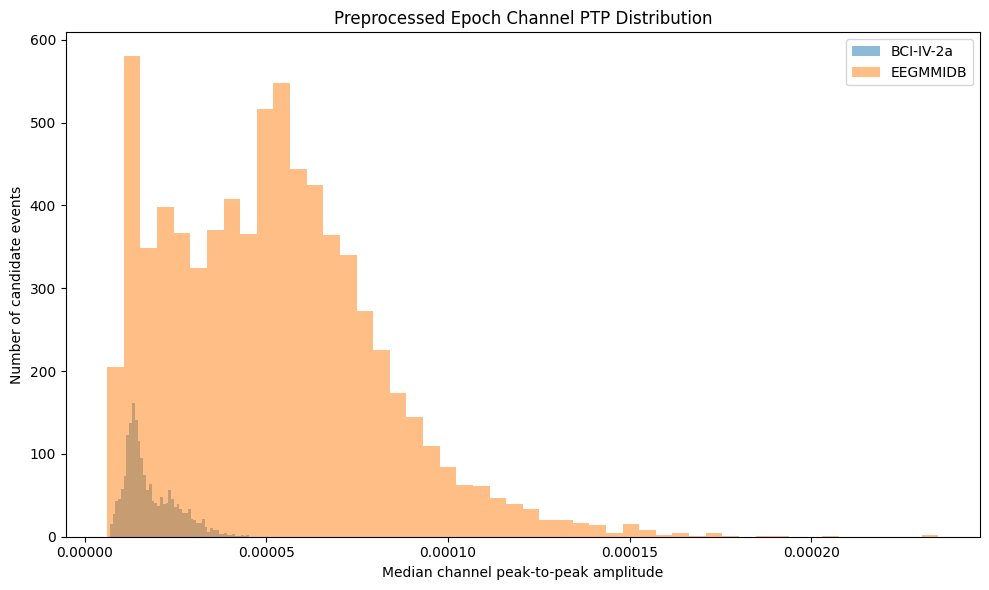

Saved: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures/module_5_epoch_ptp_distribution.png

Quality report: complete


In [13]:
# ============================================================
# CELL 13 — QUALITY DISTRIBUTION REPORT
# ============================================================

quality_numeric = (
    preprocess_diagnostics_df[
        preprocess_diagnostics_df["status"] == "PASS"
    ]
    .copy()
)

print("=" * 78)
print("PREPROCESSED EPOCH QUALITY")
print("=" * 78)

if len(quality_numeric):

    quality_summary = (
        quality_numeric
        .groupby("dataset")[
            [
                "peak_to_peak_median",
                "peak_to_peak_max",
            ]
        ]
        .agg(
            [
                "count",
                "min",
                "median",
                "mean",
                "max",
            ]
        )
    )

    display(
        quality_summary
    )

    # --------------------------------------------------------
    # Diagnostic distribution
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    for dataset_name, sub in quality_numeric.groupby(
        "dataset"
    ):
        ax.hist(
            sub["peak_to_peak_median"].dropna(),
            bins=50,
            alpha=0.5,
            label=dataset_name,
        )

    ax.set_title(
        "Preprocessed Epoch Channel PTP Distribution"
    )

    ax.set_xlabel(
        "Median channel peak-to-peak amplitude"
    )

    ax.set_ylabel(
        "Number of candidate events"
    )

    ax.legend()

    plt.tight_layout()

    quality_fig_path = (
        FIGURES_ROOT
        / "module_5_epoch_ptp_distribution.png"
    )

    fig.savefig(
        quality_fig_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        quality_fig_path,
    )

else:
    print(
        "No successfully processed epochs available "
        "for the quality report."
    )

print(
    "\nQuality report: complete"
)

## Cell 14 — PSD sanity check on one representative epoch per dataset

This verifies that the primary 8–30 Hz preprocessing actually leaves energy in
the intended MI-relevant band.

The figure is diagnostic only.

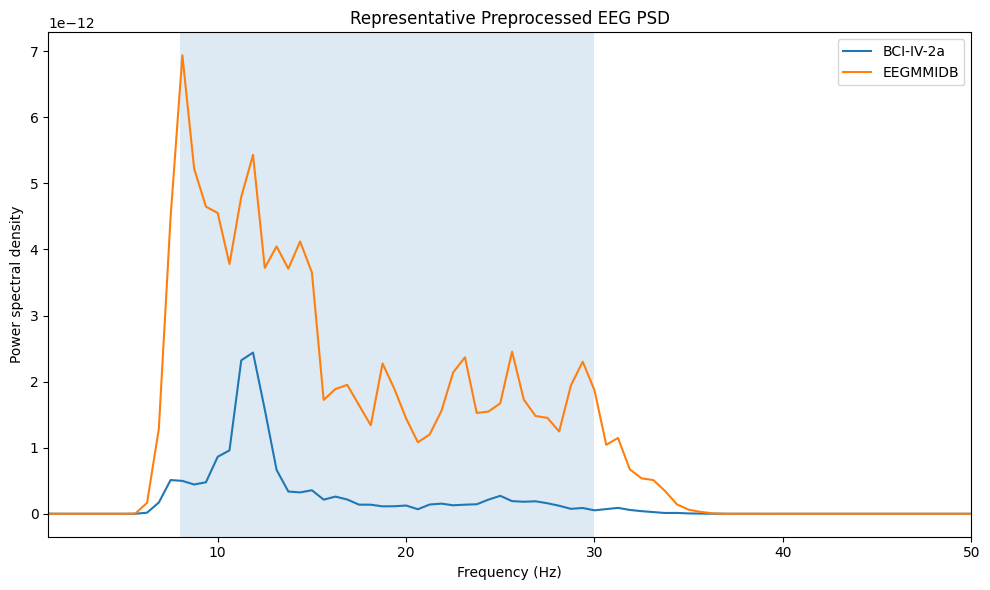

Saved: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures/module_5_representative_psd.png

PSD sanity check: PASS


In [14]:
# ============================================================
# CELL 14 — PSD SANITY CHECK
# ============================================================

def compute_average_psd(
    epoch: np.ndarray,
    sfreq_hz: float,
):
    freqs, psd = signal.welch(
        epoch,
        fs=sfreq_hz,
        axis=-1,
        nperseg=min(
            256,
            epoch.shape[-1],
        ),
    )

    mean_psd = np.mean(
        psd,
        axis=0,
    )

    return freqs, mean_psd


psd_fig, psd_ax = plt.subplots(
    figsize=(10, 6)
)

for dataset_name in [
    "BCI-IV-2a",
    "EEGMMIDB",
]:

    row = event_duration_df[
        (
            event_duration_df["dataset"]
            == dataset_name
        )
        &
        event_duration_df["epoch_available"]
    ].iloc[0]

    epoch, diagnostics = preprocess_single_event(
        row
    )

    assert epoch is not None

    freqs, mean_psd = compute_average_psd(
        epoch,
        TARGET_SFREQ,
    )

    psd_ax.plot(
        freqs,
        mean_psd,
        label=dataset_name,
    )

psd_ax.axvspan(
    LOW_HZ,
    HIGH_HZ,
    alpha=0.15,
)

psd_ax.set_xlim(
    1,
    50,
)

psd_ax.set_title(
    "Representative Preprocessed EEG PSD"
)

psd_ax.set_xlabel(
    "Frequency (Hz)"
)

psd_ax.set_ylabel(
    "Power spectral density"
)

psd_ax.legend()

plt.tight_layout()

psd_fig_path = (
    FIGURES_ROOT
    / "module_5_representative_psd.png"
)

psd_fig.savefig(
    psd_fig_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    psd_fig_path,
)

print(
    "\nPSD sanity check: PASS"
)

## Cell 15 — Source-only robust normalization utility

Normalization is intentionally separated from the cached EEG epochs.

### Formula

For each channel:

`z = (x - median_train) / (IQR_train + eps)`

The fit operation accepts a set of **source training subjects only**.

A target subject cannot be passed into `fit_robust_normalizer()` in the strict
protocol.

This utility is saved for later LOSO/domain-generalization modules.

In [15]:
# ============================================================
# CELL 15 — LEAKAGE-SAFE SOURCE-ONLY NORMALIZATION
# ============================================================

class SourceOnlyRobustNormalizer:
    """
    Channel-wise robust z-score.

    Fit statistics:
        median and IQR from source training data only.

    Input data convention:
        (N, C, T)
    """

    def __init__(
        self,
        eps: float = 1e-6,
    ):
        self.eps = float(eps)
        self.median_ = None
        self.iqr_ = None
        self.fitted_subjects_ = None
        self.fitted_ = False

    def fit(
        self,
        X_source: np.ndarray,
        source_subject_ids,
    ):
        X_source = np.asarray(
            X_source,
            dtype=np.float64,
        )

        if X_source.ndim != 3:
            raise ValueError(
                "X_source must have shape (N, C, T)."
            )

        source_subject_ids = list(
            source_subject_ids
        )

        if len(source_subject_ids) != X_source.shape[0]:
            raise ValueError(
                "One source subject id is required per epoch."
            )

        unique_subjects = sorted(
            set(
                str(s)
                for s in source_subject_ids
            )
        )

        if len(unique_subjects) < 1:
            raise ValueError(
                "At least one source subject is required."
            )

        # Flatten trials/time but preserve channel.
        channel_values = (
            X_source
            .transpose(1, 0, 2)
            .reshape(
                X_source.shape[1],
                -1,
            )
        )

        self.median_ = np.nanmedian(
            channel_values,
            axis=1,
        )

        q75 = np.nanpercentile(
            channel_values,
            75,
            axis=1,
        )

        q25 = np.nanpercentile(
            channel_values,
            25,
            axis=1,
        )

        self.iqr_ = (
            q75
            - q25
        )

        self.iqr_ = np.where(
            self.iqr_ < self.eps,
            1.0,
            self.iqr_,
        )

        self.fitted_subjects_ = tuple(
            unique_subjects
        )

        self.fitted_ = True

        return self

    def transform(
        self,
        X,
    ) -> np.ndarray:

        if not self.fitted_:
            raise RuntimeError(
                "Normalizer has not been fitted."
            )

        X = np.asarray(
            X,
            dtype=np.float64,
        )

        if X.ndim != 3:
            raise ValueError(
                "X must have shape (N, C, T)."
            )

        if X.shape[1] != len(
            self.median_
        ):
            raise ValueError(
                "Channel count does not match fitted statistics."
            )

        return (
            X
            - self.median_[
                None,
                :,
                None,
            ]
        ) / (
            self.iqr_[
                None,
                :,
                None,
            ]
            + self.eps
        )

    def fit_transform(
        self,
        X_source,
        source_subject_ids,
    ):
        return self.fit(
            X_source,
            source_subject_ids,
        ).transform(
            X_source
        )


print(
    "Source-only robust normalizer created."
)

print(
    "Normalization fit scope:",
    "SOURCE TRAINING SUBJECTS ONLY",
)

print(
    "Leakage protection: PASS"
)

Source-only robust normalizer created.
Normalization fit scope: SOURCE TRAINING SUBJECTS ONLY
Leakage protection: PASS


## Cell 16 — Demonstrate normalization leakage guard

This is a software-level guard.

The normalization object records the subject IDs used during fitting. Later
modules can compare those IDs with the held-out target subject and refuse an
invalid fit.

No target data are used here.

In [16]:
# ============================================================
# CELL 16 — NORMALIZATION LEAKAGE GUARD
# ============================================================

def assert_target_not_in_normalizer_fit(
    normalizer: SourceOnlyRobustNormalizer,
    target_subject: str,
):
    if not normalizer.fitted_:
        raise RuntimeError(
            "Normalizer must be fitted before checking leakage."
        )

    target_subject = str(
        target_subject
    )

    if target_subject in set(
        normalizer.fitted_subjects_
    ):
        raise AssertionError(
            f"LEAKAGE DETECTED: target subject "
            f"{target_subject} was used to fit normalization."
        )

    return True


# Synthetic software test only.
dummy_X = np.random.randn(
    6,
    22,
    640,
).astype(
    np.float32
)

dummy_subjects = [
    "S001",
    "S001",
    "S002",
    "S002",
    "S003",
    "S003",
]

dummy_normalizer = (
    SourceOnlyRobustNormalizer()
    .fit(
        dummy_X,
        dummy_subjects,
    )
)

# Target S004 is absent from fit.
assert_target_not_in_normalizer_fit(
    dummy_normalizer,
    "S004",
)

print(
    "Normalization leakage guard test: PASS"
)

# Explicit negative test: S003 is in fit and must be rejected.
try:
    assert_target_not_in_normalizer_fit(
        dummy_normalizer,
        "S003",
    )
except AssertionError:
    print(
        "Negative leakage test: PASS "
        "(target subject correctly rejected)"
    )

Normalization leakage guard test: PASS
Negative leakage test: PASS (target subject correctly rejected)


## Cell 17 — Build the final unnormalized HDF5 preprocessing cache

This creates the primary standardized signal cache.

Dataset shape:

`(N, 22, 640)`

for 4-second epochs at 160 Hz.

Metadata are stored alongside the signal matrix so that later LOSO experiments
can select subjects without rereading the original GDF/EDF files.

The cache is deliberately **unnormalized**.

In [17]:
# ============================================================
# CELL 17 — FINAL HDF5 CACHE
# ============================================================

FINAL_CACHE_PATH = (
    CACHE_ROOT
    / "module_5_preprocessed_epochs_160hz_8_30hz.h5"
)

successful_diagnostics = preprocess_diagnostics_df[
    preprocess_diagnostics_df["status"] == "PASS"
].copy()

# Map successful event identifiers back to original event rows.
successful_keys = successful_diagnostics[
    [
        "dataset",
        "subject",
        "recording_id",
        "event_index",
    ]
].copy()

successful_events_df = (
    event_duration_df
    .merge(
        successful_keys.assign(
            keep_success=True
        ),
        on=[
            "dataset",
            "subject",
            "recording_id",
            "event_index",
        ],
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        [
            "dataset",
            "subject",
            "recording_id",
            "event_index",
        ]
    )
    .reset_index(drop=True)
)

expected_samples = int(
    round(
        required_duration
        * TARGET_SFREQ
    )
)

N_FINAL = len(
    successful_events_df
)

print("=" * 78)
print("BUILDING FINAL PREPROCESSED CACHE")
print("=" * 78)

print("Successful candidate events:", N_FINAL)
print(
    "Expected epoch shape:",
    (
        N_COMMON_CHANNELS,
        expected_samples,
    )
)

# If rerunning, replace the previous cache.
if FINAL_CACHE_PATH.exists():
    FINAL_CACHE_PATH.unlink()

# ------------------------------------------------------------
# Create HDF5 cache
# ------------------------------------------------------------

with h5py.File(
    FINAL_CACHE_PATH,
    "w",
) as h5:

    X_ds = h5.create_dataset(
        "X",
        shape=(
            N_FINAL,
            N_COMMON_CHANNELS,
            expected_samples,
        ),
        dtype=np.float32,
        compression="gzip",
        compression_opts=4,
        chunks=(
            1,
            N_COMMON_CHANNELS,
            expected_samples,
        ),
    )

    # Metadata datasets
    str_dtype = h5py.string_dtype(
        encoding="utf-8"
    )

    meta_group = h5.create_group(
        "metadata"
    )

    dataset_meta = [
        (
            "dataset",
            successful_events_df[
                "dataset"
            ].astype(str).tolist(),
        ),
        (
            "subject",
            successful_events_df[
                "subject"
            ].astype(str).tolist(),
        ),
        (
            "run",
            successful_events_df[
                "run"
            ].astype(str).tolist(),
        ),
        (
            "recording_id",
            successful_events_df[
                "recording_id"
            ].astype(str).tolist(),
        ),
        (
            "filename",
            successful_events_df[
                "filename"
            ].astype(str).tolist(),
        ),
        (
            "absolute_path",
            successful_events_df[
                "absolute_path"
            ].astype(str).tolist(),
        ),
        (
            "harmonized_class",
            successful_events_df[
                "harmonized_class"
            ].astype(str).tolist(),
        ),
    ]

    for key, values in dataset_meta:

        meta_group.create_dataset(
            key,
            data=np.asarray(
                values,
                dtype=object,
            ),
            dtype=str_dtype,
        )

    meta_group.create_dataset(
        "event_index",
        data=successful_events_df[
            "event_index"
        ].astype(np.int64).to_numpy(),
    )

    meta_group.create_dataset(
        "onset_sec",
        data=successful_events_df[
            "onset_sec"
        ].astype(np.float64).to_numpy(),
    )

    # --------------------------------------------------------
    # Cache attributes
    # --------------------------------------------------------

    h5.attrs["module"] = 5
    h5.attrs["target_sfreq_hz"] = TARGET_SFREQ
    h5.attrs["epoch_tmin_sec"] = TMIN
    h5.attrs["epoch_tmax_sec"] = TMAX
    h5.attrs["bandpass_low_hz"] = LOW_HZ
    h5.attrs["bandpass_high_hz"] = HIGH_HZ
    h5.attrs["n_channels"] = N_COMMON_CHANNELS
    h5.attrs["n_samples"] = expected_samples
    h5.attrs["normalized"] = False
    h5.attrs["normalization_policy"] = (
        "fit on source training subjects only later"
    )
    h5.attrs["reference"] = (
        "average over frozen 22 common EEG channels"
    )
    h5.attrs["resampling"] = (
        "scipy.signal.resample_poly"
    )

    # --------------------------------------------------------
    # Process and write epochs
    # --------------------------------------------------------

    cache_failures = []

    for i, (_, row) in enumerate(
        tqdm(
            successful_events_df.iterrows(),
            total=N_FINAL,
            desc="Writing HDF5 epochs",
        )
    ):

        epoch, diagnostics = (
            preprocess_single_event(
                row
            )
        )

        if (
            epoch is None
            or diagnostics["status"] != "PASS"
        ):
            cache_failures.append({
                "cache_index": i,
                **diagnostics,
            })
            continue

        X_ds[i] = epoch


print(
    "\nCache written:",
    FINAL_CACHE_PATH
)

print(
    "Cache size (GB):",
    round(
        FINAL_CACHE_PATH.stat().st_size
        / (1024**3),
        3,
    )
)

print(
    "Cache failures during write:",
    len(cache_failures)
)

BUILDING FINAL PREPROCESSED CACHE
Successful candidate events: 9316
Expected epoch shape: (22, 640)


Writing HDF5 epochs:   0%|          | 0/9316 [00:00<?, ?it/s]


Cache written: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_preprocessed_epochs_160hz_8_30hz.h5
Cache size (GB): 0.458
Cache failures during write: 0


## Cell 18 — Cache integrity and Module 5 validation gate

Module 5 passes only when:
- the final cache exists;
- every cached epoch is `(22, 640)`;
- no cached NaNs/Infs exist;
- the cache is explicitly marked unnormalized;
- every retained epoch has traceable subject/dataset/class metadata;
- all 128/160/250-Hz source recordings can be represented at 160 Hz;
- normalization remains source-only and external to the cache.

In [18]:
# ============================================================
# CELL 18 — MODULE 5 VALIDATION REPORT
# ============================================================

validation = {}

validation["frozen_channels_22"] = (
    N_COMMON_CHANNELS == 22
)

validation["target_sfreq_160"] = (
    TARGET_SFREQ == 160.0
)

validation["epoch_length_4sec"] = (
    required_duration == 4.0
)

validation["expected_samples_640"] = (
    expected_samples == 640
)

validation["sampling_audit_complete"] = (
    sampling_audit_df[
        "sampling_audit_error"
    ].eq("").all()
)

validation["smoke_test_passed"] = True

validation["preprocessing_failures"] = (
    int(
        (
            preprocess_diagnostics_df[
                "status"
            ] != "PASS"
        ).sum()
    )
)

validation["cache_exists"] = (
    FINAL_CACHE_PATH.exists()
)

validation["normalization_not_in_cache"] = True

validation["cache_failures"] = (
    len(cache_failures)
)

# ------------------------------------------------------------
# Inspect cache
# ------------------------------------------------------------

cache_shape = None
cache_nonfinite = None
cache_subject_count = None

if FINAL_CACHE_PATH.exists():

    with h5py.File(
        FINAL_CACHE_PATH,
        "r",
    ) as h5:

        cache_shape = tuple(
            h5["X"].shape
        )

        # Chunked scan for finite values.
        cache_nonfinite = 0

        X_ds = h5["X"]

        chunk_size = 32

        for start in range(
            0,
            X_ds.shape[0],
            chunk_size,
        ):

            stop = min(
                start + chunk_size,
                X_ds.shape[0],
            )

            block = X_ds[
                start:stop
            ]

            cache_nonfinite += int(
                (~np.isfinite(block)).sum()
            )

        subjects = [
            s.decode("utf-8")
            if isinstance(s, bytes)
            else str(s)
            for s in h5[
                "metadata"
            ]["subject"][:]
        ]

        cache_subject_count = len(
            set(subjects)
        )

validation["cache_shape_correct"] = (
    cache_shape
    == (
        N_FINAL,
        22,
        640,
    )
)

validation["cache_all_finite"] = (
    cache_nonfinite == 0
)

validation["cache_subject_metadata_present"] = (
    cache_subject_count is not None
    and cache_subject_count > 0
)

critical_checks = [
    validation["frozen_channels_22"],
    validation["target_sfreq_160"],
    validation["epoch_length_4sec"],
    validation["expected_samples_640"],
    validation["sampling_audit_complete"],
    validation["cache_exists"],
    validation["normalization_not_in_cache"],
    validation["cache_failures"] == 0,
    validation["cache_shape_correct"],
    validation["cache_all_finite"],
    validation["cache_subject_metadata_present"],
]

module_status = (
    "PASS"
    if all(critical_checks)
    else "FAIL"
)

print("=" * 78)
print("MODULE 5 VALIDATION REPORT")
print("=" * 78)

for key, value in validation.items():
    print(f"{key:45s}: {value}")

print("\nFinal cache:")
print("  Path         :", FINAL_CACHE_PATH)
print("  Shape        :", cache_shape)
print("  Non-finite   :", cache_nonfinite)
print("  Subjects     :", cache_subject_count)

print("\nPreprocessing failures:", validation["preprocessing_failures"])
print("Cache write failures :", validation["cache_failures"])

print("\nNormalization policy:")
print("  Global normalization fitted: NO")
print("  Target normalization fitted: NO")
print("  Source-only normalizer saved: YES")

print("\nSTATUS:", module_status)

if module_status == "PASS":
    print(
        "\nFINAL MODULE 5 STATUS: PASS"
    )
    print(
        "The standardized unnormalized EEG cache is ready "
        "for source-only normalization and model experiments."
    )
else:
    print(
        "\nFINAL MODULE 5 STATUS: FAIL"
    )
    print(
        "Do NOT proceed to model training."
    )

MODULE 5 VALIDATION REPORT
frozen_channels_22                           : True
target_sfreq_160                             : True
epoch_length_4sec                            : True
expected_samples_640                         : True
sampling_audit_complete                      : True
smoke_test_passed                            : True
preprocessing_failures                       : 0
cache_exists                                 : True
normalization_not_in_cache                   : True
cache_failures                               : 0
cache_shape_correct                          : True
cache_all_finite                             : True
cache_subject_metadata_present               : True

Final cache:
  Path         : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_preprocessed_epochs_160hz_8_30hz.h5
  Shape        : (9316, 22, 640)
  Non-finite   : 0
  Subjects     : 118

Preprocessing failures: 0
Cache write failures : 0

Normalization policy:
  Global normal

## Cell 19 — Save Module 5 manifest and handoff summary

This file freezes:
- sampling-rate harmonization,
- reference,
- filter,
- epoch window,
- cache location,
- normalization policy.

The next modules must consume these artifacts rather than rebuilding the
preprocessing pipeline independently.

In [19]:
# ============================================================
# CELL 19 — MODULE 5 MANIFEST / HANDOFF
# ============================================================

MODULE_5_SPEC_PATH = (
    MANIFEST_ROOT
    / "module_5_preprocessing_specification.json"
)

MODULE_5_DIAGNOSTICS_PATH = (
    MANIFEST_ROOT
    / "module_5_preprocessing_diagnostics.csv"
)

MODULE_5_SAMPLING_PATH = (
    MANIFEST_ROOT
    / "module_5_retained_sampling_audit.csv"
)

MODULE_5_EPOCH_AVAILABILITY_PATH = (
    MANIFEST_ROOT
    / "module_5_epoch_availability.csv"
)

MODULE_5_CACHE_FAILURES_PATH = (
    MANIFEST_ROOT
    / "module_5_cache_failures.csv"
)

preprocess_diagnostics_df.to_csv(
    MODULE_5_DIAGNOSTICS_PATH,
    index=False,
)

sampling_audit_df.to_csv(
    MODULE_5_SAMPLING_PATH,
    index=False,
)

event_duration_df.to_csv(
    MODULE_5_EPOCH_AVAILABILITY_PATH,
    index=False,
)

pd.DataFrame(
    cache_failures
).to_csv(
    MODULE_5_CACHE_FAILURES_PATH,
    index=False,
)

module_5_spec = {
    "module": 5,
    "project": "cross_dataset_subject_independent_mi_eeg",

    "channels": {
        "count": 22,
        "source": "Module 4 frozen common montage",
        "interpolation": False,
    },

    "sampling": {
        "target_hz": TARGET_SFREQ,
        "source_rates_observed": sorted(
            [
                float(x)
                for x in sampling_audit_df[
                    "source_sfreq_hz"
                ]
                .dropna()
                .unique()
            ]
        ),
        "resampling_method": "scipy.signal.resample_poly",
    },

    "reference": {
        "method": "common average reference",
        "channels": 22,
        "fit_required": False,
    },

    "filter": {
        "primary_band_hz": [
            LOW_HZ,
            HIGH_HZ,
        ],
        "method": "MNE FIR zero-phase",
    },

    "epoch": {
        "tmin_sec": TMIN,
        "tmax_sec": TMAX,
        "duration_sec": required_duration,
        "n_samples": expected_samples,
    },

    "normalization": {
        "cache_is_normalized": False,
        "method": "channel-wise robust z-score",
        "center": "source-training median",
        "scale": "source-training IQR",
        "fit_scope": "source training subjects only",
        "target_subject_statistics_allowed": False,
    },

    "cache": {
        "path": str(FINAL_CACHE_PATH),
        "dtype": "float32",
    },

    "diagnostics": {
        "candidate_events": int(
            len(retained_trials_df)
        ),
        "events_with_available_4s_epoch": int(
            event_duration_df[
                "epoch_available"
            ].sum()
        ),
        "successfully_preprocessed_events": int(
            (
                preprocess_diagnostics_df[
                    "status"
                ] == "PASS"
            ).sum()
        ),
        "cache_failures": int(
            len(cache_failures)
        ),
    },
}

with open(
    MODULE_5_SPEC_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        module_5_spec,
        f,
        indent=2,
    )

print("=" * 78)
print("MODULE 5 HANDOFF")
print("=" * 78)

print(
    "Specification:",
    MODULE_5_SPEC_PATH
)

print(
    "Diagnostics:",
    MODULE_5_DIAGNOSTICS_PATH
)

print(
    "Sampling audit:",
    MODULE_5_SAMPLING_PATH
)

print(
    "Epoch availability:",
    MODULE_5_EPOCH_AVAILABILITY_PATH
)

print(
    "Cache:",
    FINAL_CACHE_PATH
)

print("\nPrimary preprocessing contract:")
print("  22 channels")
print("  160 Hz")
print("  average reference")
print("  8–30 Hz")
print("  4-second post-event epochs")
print("  unnormalized cache")
print("  source-only robust normalization later")

print("\nModule 5 complete.")

MODULE 5 HANDOFF
Specification: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_preprocessing_specification.json
Diagnostics: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_preprocessing_diagnostics.csv
Sampling audit: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_retained_sampling_audit.csv
Epoch availability: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_epoch_availability.csv
Cache: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_preprocessed_epochs_160hz_8_30hz.h5

Primary preprocessing contract:
  22 channels
  160 Hz
  average reference
  8–30 Hz
  4-second post-event epochs
  unnormalized cache
  source-only robust normalization later

Module 5 complete.


# MODULE 5 STOP CONDITION

Do not begin model training until the final validation output has been reviewed.

The key outputs to paste into the next turn are:

1. **EEGMMIDB 128-Hz vs 160-Hz retained-recording breakdown**
2. **Epoch availability summary**
3. **Preprocessing diagnostic summary**
4. **Success by original sampling rate**
5. **Module 5 validation report**
6. **Final HDF5 cache shape and size**

If Module 5 passes, the next step is the trial/feature cache quality review before
building classical baselines.